# Test-Time Augmentation (TTA, 2-view) on CIFAR-10

## Why this notebook

The SOTA soft-voting ensemble (ResNet18 + DenseNet121) has plateaued. **TTA
with 2 views (original + horizontal flip)** is a free, retraining-free win: it
averages the softmax over two views of each test image.

On this dataset the **2-view** configuration outperforms the 10-view multi-crop
recipe (which was built for native-resolution images and hurts the upsampled
32x32 CIFAR-10 inputs). This notebook demonstrates and visualises the 2-view
TTA configuration:
1. Baseline (single pass) vs **TTA 2-view** on the full test set + isolated cat/dog.
2. Confusion matrices and a **stacked-bar error analysis** comparing
   misclassification type & count between baseline and TTA.
3. **ROC curves** (per-class OvR + micro-average) for both.
4. Where TTA changes predictions.

## TL;DR

$$\hat{y} = \arg\max_c \; \frac{1}{N}\sum_{k=1}^{N} \, p_c\big(f(\text{view}_k(x))\big), \quad N=2$$

Run each test image (original + horizontal flip), average the two softmax
vectors, predict the argmax. No training changes.

## 1. What TTA is (recap)

During training we augment (flips, crops) so the model is robust. **Test-time
augmentation** applies the same idea at inference: run several augmented
"views" of each test image and average the predictions. A mistake in one view
is "voted out" by the others.

### 2-view horizontal-flip recipe
1. Take the test image at 224x224.
2. Build 2 views: **original** and **horizontal flip**.
3. Softmax each view, average the 2 probability vectors, predict the argmax.

Two views double inference cost but recover most of the available gain, and —
unlike aggressive multi-crop on tiny images — preserve the full object in every
view.

## 2. Setup & Data

One test loader at 224x224 (`shuffle=False`, so results align sample-for-sample).

In [ ]:
import json, sys, os
from pathlib import Path

import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Robust root detection (matches practice_2 convention): works whether the
# notebook is launched from the repo root or from notebooks/.
_cwd = Path(os.getcwd()).resolve()
if (_cwd / "src").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "src").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.build_model import build_resnet18, build_densenet121
from src.eval.evaluate_model import load_checkpoint, CIFAR10_CLASSES

CAT_IDX, DOG_IDX = 3, 5
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
DATA_ROOT = str(PROJECT_ROOT / "data" / "raw")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

def loader_for(resize=224, batch_size=64):
    tform = transforms.Compose([
        transforms.Resize(resize),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    ds = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, transform=tform)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

loader224 = loader_for(224)
print("test samples:", len(loader224.dataset))

Device: cuda
test samples: 10000


## 3. Load the SOTA Ensemble & TTA Helpers

In [2]:
# ---- Load SOTA models ----
ckpt = PROJECT_ROOT / "experiments" / "checkpoints"
rn = build_resnet18(num_classes=10, mode="finetune", device=device)
dn = build_densenet121(num_classes=10, mode="finetune", device=device)
rn = load_checkpoint(rn, str(ckpt / "ResNet18-sota_best.pt"), device)
dn = load_checkpoint(dn, str(ckpt / "DenseNet121-sota_best.pt"), device)
rn.eval(); dn.eval()
print("Loaded ResNet18-sota and DenseNet121-sota.")

@torch.inference_mode()
def softmax_vote_models(a, b, views):
    pa = torch.stack([torch.softmax(a(v), dim=1) for v in views]).mean(0)
    pb = torch.stack([torch.softmax(b(v), dim=1) for v in views]).mean(0)
    return (0.5 * (pa + pb)).cpu()

@torch.inference_mode()
def predict(loader, view_fn, a, b):
    probs, ys = [], []
    for x, y in loader:
        probs.append(softmax_vote_models(a, b, view_fn(x.to(device))))
        ys.append(y)
    return torch.cat(probs).numpy(), torch.cat(ys).numpy()

def view_single(x):            # baseline: the image itself (1 view)
    return [x]

def view_hflip(x):             # TTA 2-view: original + horizontal flip
    return [x, torch.flip(x, dims=[3])]

def full_metrics(probs, targets):
    preds = np.argmax(probs, axis=1)
    acc = (preds == targets).mean() * 100.0
    cm = confusion_matrix(targets, preds, labels=list(range(10)))
    rep = classification_report(targets, preds, labels=list(range(10)),
                                output_dict=True, zero_division=0)
    return acc, rep["macro avg"]["f1-score"], cm

def isolated_catdog(probs, targets):
    mask = (targets == CAT_IDX) | (targets == DOG_IDX)
    t, p = targets[mask], np.argmax(probs[mask], axis=1)
    acc = (p == t).mean() * 100.0
    cross = int(((t == CAT_IDX) & (p == DOG_IDX)).sum()
                + ((t == DOG_IDX) & (p == CAT_IDX)).sum())
    return acc, cross

c:\document\Study documents\Deeplearning_Course\.venv\Lib\site-packages\torch\nn\modules\module.py:1369: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  return t.to(


Loaded ResNet18-sota and DenseNet121-sota.


## 4. Baseline — single forward pass (no TTA)

In [3]:
p_base, y = predict(loader224, view_single, rn, dn)
acc_base, f1_base, cm_base = full_metrics(p_base, y)
iso_base, cross_base = isolated_catdog(p_base, y)
print(f"Baseline (1 view)  : full_acc={acc_base:.2f}%  macro_f1={f1_base:.4f}  "
      f"isolated={iso_base:.2f}%  cross_conf={cross_base}")

Baseline (1 view)  : full_acc=96.87%  macro_f1=0.9687  isolated=93.45%  cross_conf=86


## 5. TTA — Horizontal Flip (2 views)

Original + horizontal flip, softmax averaged. This is the recommended 2-view
configuration.

In [4]:
p_tta, _ = predict(loader224, view_hflip, rn, dn)
acc_tta, f1_tta, cm_tta = full_metrics(p_tta, y)
iso_tta, cross_tta = isolated_catdog(p_tta, y)
print(f"TTA 2-view (hflip) : full_acc={acc_tta:.2f}%  macro_f1={f1_tta:.4f}  "
      f"isolated={iso_tta:.2f}%  cross_conf={cross_tta}   (dAcc={acc_tta-acc_base:+.2f}%)")

TTA 2-view (hflip) : full_acc=97.12%  macro_f1=0.9712  isolated=94.00%  cross_conf=76   (dAcc=+0.25%)


## 6. Comparison — Baseline vs TTA 2-view

In [5]:
rows = [
    ("Baseline (1 view)",       acc_base, iso_base, cross_base, 1),
    ("TTA horizontal flip (2)", acc_tta,  iso_tta,  cross_tta,  2),
]
print(f"{'Method':26s} {'full_acc':>9s} {'dAcc':>7s} {'isolated':>9s} "
      f"{'cross_conf':>10s} {'views':>5s}")
for name, acc, iso, cross, n in rows:
    print(f"{name:26s} {acc:8.2f}% {acc-acc_base:+6.2f}% {iso:8.2f}% "
          f"{cross:>9d} {n:>5d}")
print(f"\nTTA 2-view improves full accuracy by {acc_tta-acc_base:+.2f}% and cuts "
      f"cat/dog cross-confusions {cross_base} -> {cross_tta}.")

Method                      full_acc    dAcc  isolated cross_conf views
Baseline (1 view)             96.87%  +0.00%    93.45%        86     1
TTA horizontal flip (2)       97.12%  +0.25%    94.00%        76     2

TTA 2-view improves full accuracy by +0.25% and cuts cat/dog cross-confusions 86 -> 76.


## 7. Confusion Matrices (Baseline vs TTA 2-view)

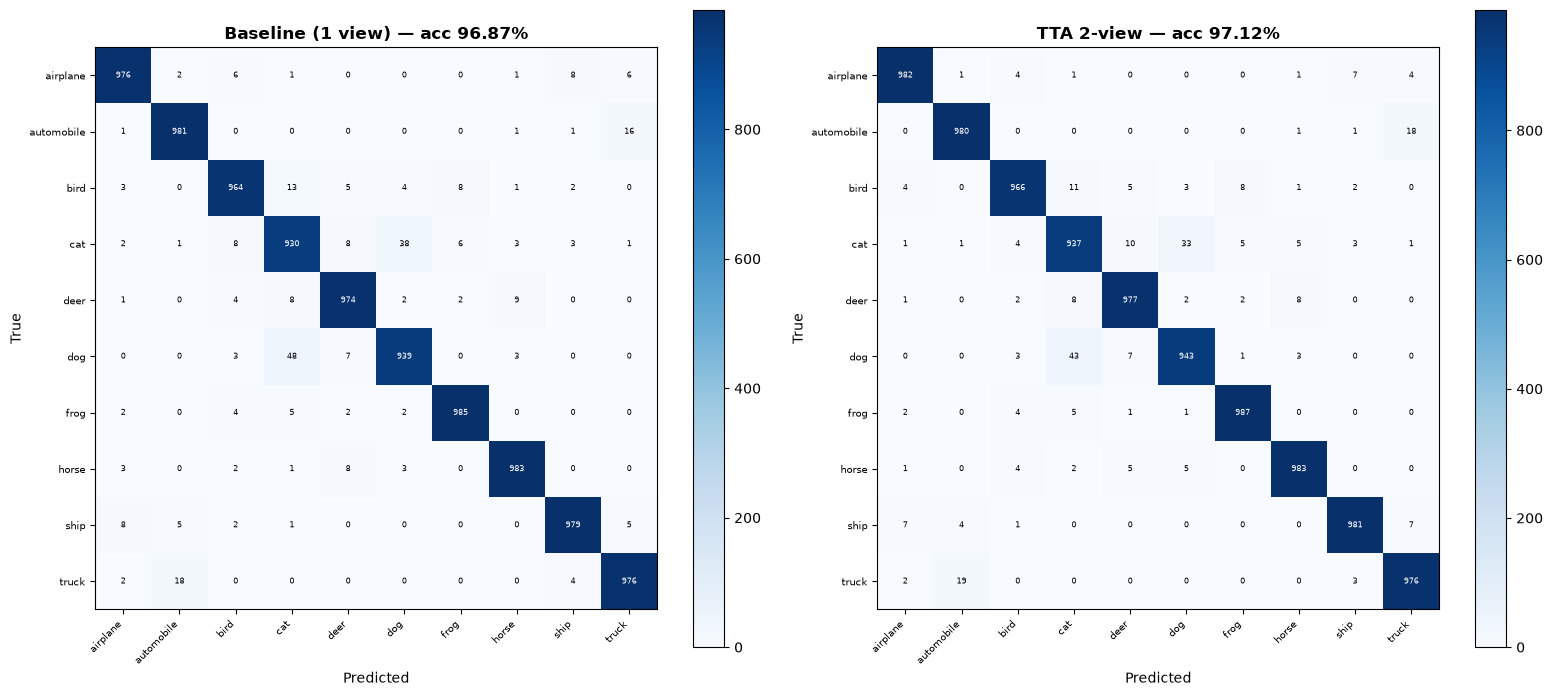

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, cm, title in [
        (axes[0], cm_base, f"Baseline (1 view) — acc {acc_base:.2f}%"),
        (axes[1], cm_tta,  f"TTA 2-view — acc {acc_tta:.2f}%")]:
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(CIFAR10_CLASSES, fontsize=7)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold")
    for r in range(10):
        for c in range(10):
            ax.text(c, r, str(cm[r, c]), ha="center", va="center", fontsize=6,
                    color="white" if cm[r, c] > cm.max() * 0.6 else "black")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "plots" / "tta2_confusion_matrices.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 8. Error Analysis — Stacked Bar (Baseline vs TTA 2-view)

Analogous to the "Error Analysis: Misclassified Class Distribution & Confusion
Pairs" plot, but as a **double stacked bar**: for each true class, two stacked
bars (baseline and TTA 2-view), each stacked by the *predicted (wrong) class*,
highlighting how the type and count of misclassifications change under TTA.

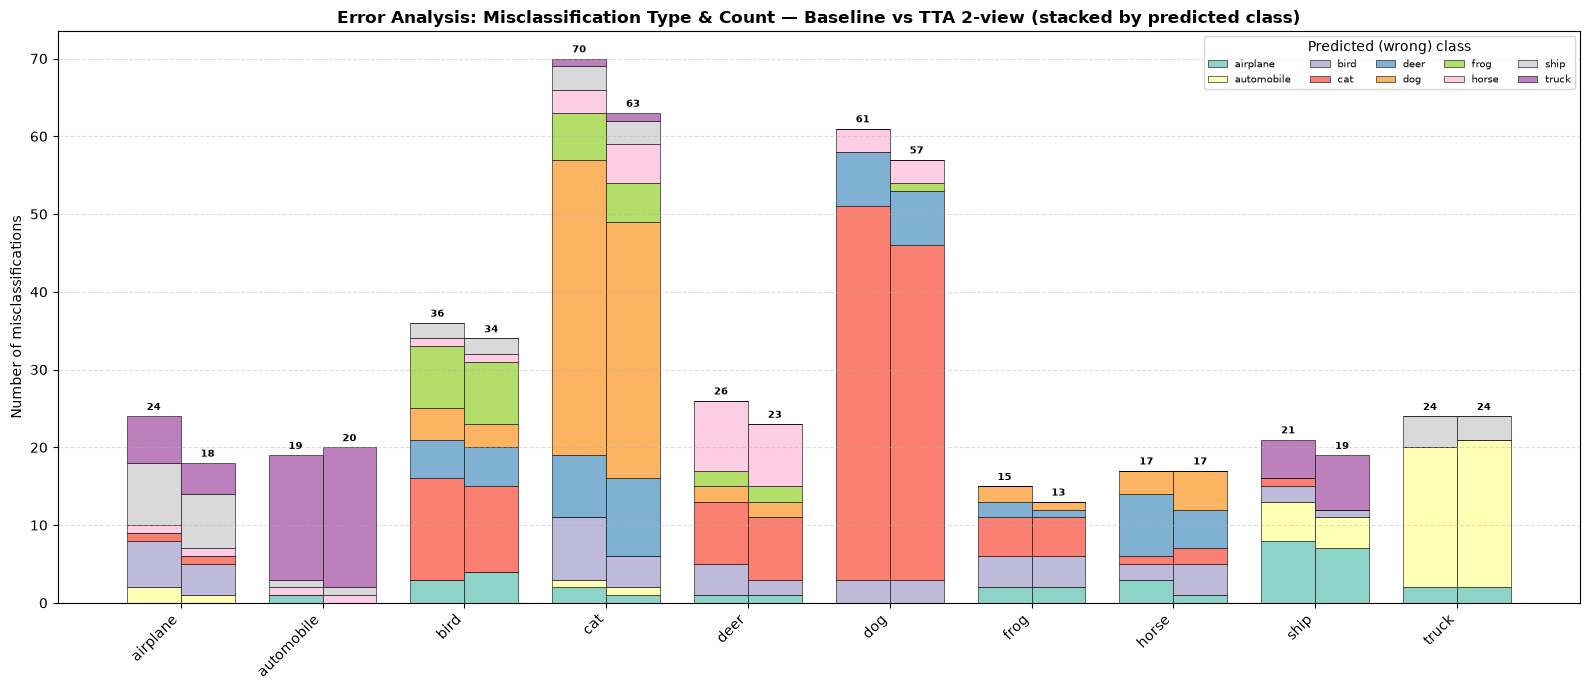

Total misclassifications — baseline: 313  TTA 2-view: 288  (d -25)


In [7]:
def plot_confusion_stacked(cm_no, cm_tta, class_names):
    """Double stacked bar: per-true-class misclassifications stacked by the
    predicted (wrong) class, comparing baseline (no TTA) vs TTA 2-view."""
    n = len(class_names); x = np.arange(n); width = 0.38
    fig, ax = plt.subplots(figsize=(16, 7))
    cmap = plt.cm.Set3
    for cm, off, label in [
            (cm_no,  -width / 2, "Baseline (no TTA)"),
            (cm_tta, +width / 2, "TTA 2-view")]:
        bottom = np.zeros(n)
        for j in range(n):
            seg = cm[:, j].astype(float).copy()
            seg[j] = 0.0  # off-diagonal only (misclassifications)
            ax.bar(x + off, seg, width, bottom=bottom, color=cmap(j),
                   edgecolor="black", linewidth=0.4,
                   label=class_names[j] if off < 0 else "_nolegend_")
            bottom += seg
        for i in range(n):
            if bottom[i] > 0:
                ax.text(x[i] + off, bottom[i] + 0.5, f"{int(bottom[i])}",
                        ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_ylabel("Number of misclassifications")
    ax.set_title("Error Analysis: Misclassification Type & Count — "
                 "Baseline vs TTA 2-view (stacked by predicted class)",
                 fontweight="bold")
    ax.legend(title="Predicted (wrong) class", ncol=5, fontsize=7, loc="upper right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "experiments" / "plots" / "tta2_error_stacked.png",
                dpi=300, bbox_inches="tight")
    plt.show()

    off_no = cm_no.copy(); np.fill_diagonal(off_no, 0)
    off_tta = cm_tta.copy(); np.fill_diagonal(off_tta, 0)
    print(f"Total misclassifications — baseline: {int(off_no.sum())}  "
          f"TTA 2-view: {int(off_tta.sum())}  (d {int(off_tta.sum() - off_no.sum()):+d})")

plot_confusion_stacked(cm_base, cm_tta, CIFAR10_CLASSES)

## 9. ROC Curves (Baseline vs TTA 2-view)

Per-class One-vs-Rest (OvR) ROC curves plus the micro-average ROC for each
configuration, with AUC.

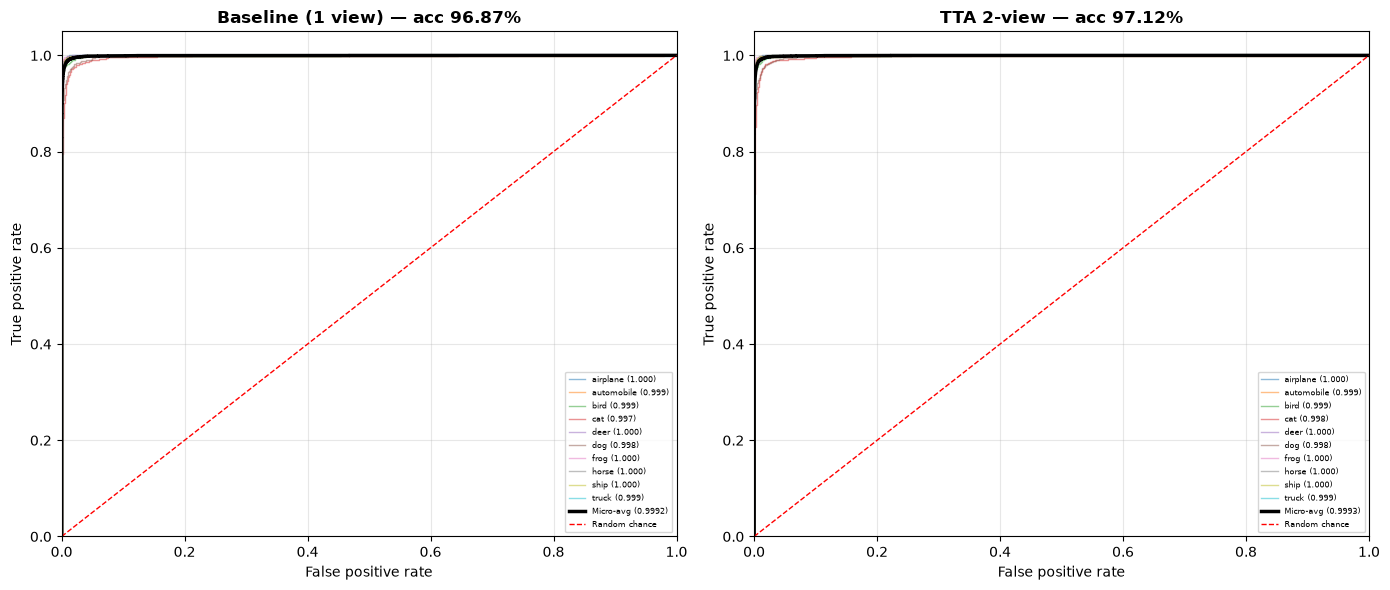

Micro-AUC — baseline: 0.9992 | TTA 2-view: 0.9993


In [8]:
def plot_roc(probs, targets, title, ax):
    y_bin = label_binarize(targets, classes=list(range(10)))
    fpr_m, tpr_m, _ = roc_curve(y_bin.ravel(), probs.ravel())
    auc_m = auc(fpr_m, tpr_m)
    for c in range(10):
        fpr_c, tpr_c, _ = roc_curve(y_bin[:, c], probs[:, c])
        ax.plot(fpr_c, tpr_c, lw=1.0, alpha=0.5,
                label=f"{CIFAR10_CLASSES[c]} ({auc(fpr_c, tpr_c):.3f})")
    ax.plot(fpr_m, tpr_m, "k-", lw=2.5, label=f"Micro-avg ({auc_m:.4f})")
    ax.plot([0, 1], [0, 1], "r--", lw=1.0, label="Random chance")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=6, loc="lower right"); ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_roc(p_base, y, f"Baseline (1 view) — acc {acc_base:.2f}%", axes[0])
plot_roc(p_tta,  y, f"TTA 2-view — acc {acc_tta:.2f}%", axes[1])
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "plots" / "tta2_roc_curves.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Micro-average AUC summary
from sklearn.metrics import roc_auc_score
y_bin = label_binarize(y, classes=list(range(10)))
print("Micro-AUC — baseline:", round(roc_auc_score(y_bin, p_base, average="micro"), 4),
      "| TTA 2-view:", round(roc_auc_score(y_bin, p_tta, average="micro"), 4))

## 10. Where Does TTA Change Predictions?

TTA rarely flips a confident correct answer; it mostly fixes low-confidence
errors. Here we count prediction changes and display examples TTA corrected
and broke.

Samples whose prediction changed: 98 / 10000 (0.98%)
  corrected by TTA (base wrong -> TTA right): 59
  broken by TTA    (base right -> TTA wrong): 34
  net gain: +25 samples


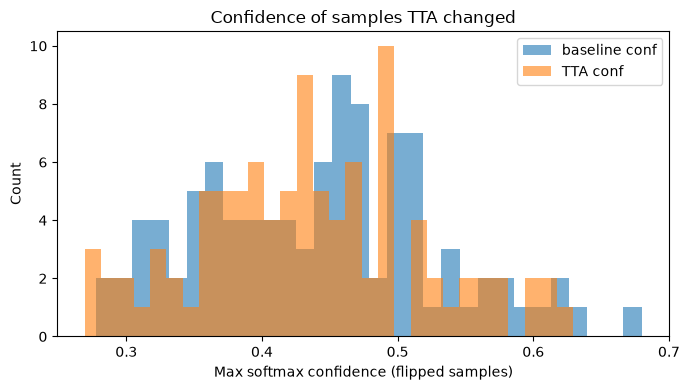

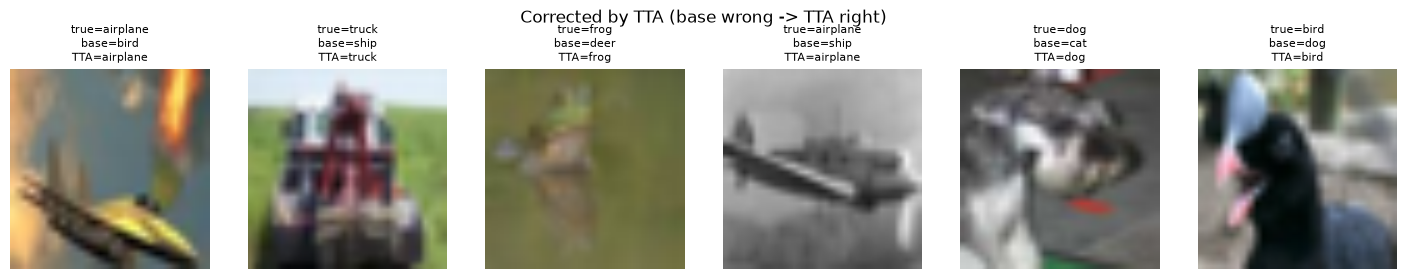

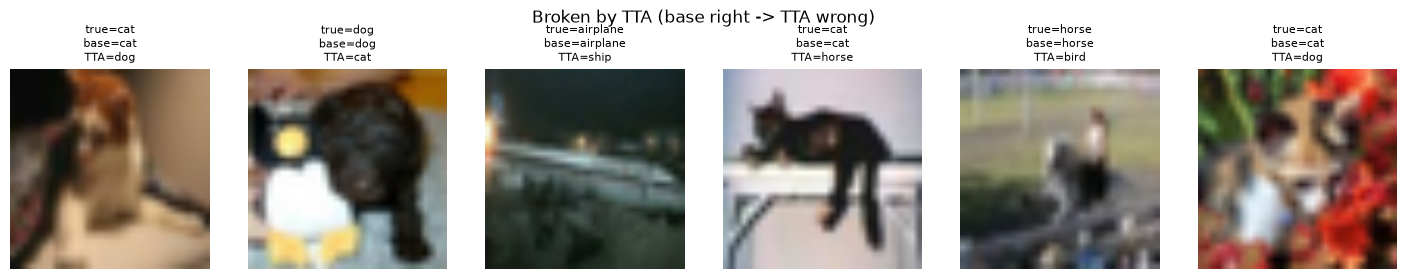

In [9]:
pred_base = np.argmax(p_base, axis=1)
pred_tta = np.argmax(p_tta, axis=1)
flipped = pred_base != pred_tta
corrected = flipped & (pred_tta == y) & (pred_base != y)
broke = flipped & (pred_base == y) & (pred_tta != y)
print(f"Samples whose prediction changed: {int(flipped.sum())} / {len(y)} "
      f"({100*flipped.sum()/len(y):.2f}%)")
print(f"  corrected by TTA (base wrong -> TTA right): {int(corrected.sum())}")
print(f"  broken by TTA    (base right -> TTA wrong): {int(broke.sum())}")
print(f"  net gain: {int(corrected.sum()) - int(broke.sum()):+d} samples")

conf_base = p_base.max(1); conf_tta = p_tta.max(1)
plt.figure(figsize=(7, 4))
plt.hist(conf_base[flipped], bins=30, alpha=0.6, label="baseline conf")
plt.hist(conf_tta[flipped], bins=30, alpha=0.6, label="TTA conf")
plt.xlabel("Max softmax confidence (flipped samples)"); plt.ylabel("Count")
plt.title("Confidence of samples TTA changed"); plt.legend(); plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "plots" / "tta2_confidence_hist.png",
            dpi=300, bbox_inches="tight")
plt.show()

def denorm(t):
    m = torch.tensor(IMAGENET_MEAN).view(3, 1, 1); s = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(t * s + m, 0, 1)

def show_samples(idx_list, title, n=6):
    if len(idx_list) == 0:
        print(f"  ({title}: no examples)"); return
    n = min(n, len(idx_list))
    fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 2.8))
    axes = np.atleast_1d(axes)
    for ax, i in zip(axes, idx_list[:n]):
        img = denorm(loader224.dataset[i][0])   # aligned index order
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(f"true={CIFAR10_CLASSES[y[i]]}\n"
                     f"base={CIFAR10_CLASSES[pred_base[i]]}\n"
                     f"TTA={CIFAR10_CLASSES[pred_tta[i]]}", fontsize=8)
        ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_samples(np.where(corrected)[0], "Corrected by TTA (base wrong -> TTA right)")
show_samples(np.where(broke)[0], "Broken by TTA (base right -> TTA wrong)")

## 11. Practical Considerations

- **Cost**: 2 views = 2x inference compute; no training cost.
- **View choice**: horizontal flip matches the training augmentation and
  preserves the full object — ideal for CIFAR-10 (32x32 upsampled), where
  aggressive multi-crop cropping hurts.
- **Averaging**: average **softmax probabilities** (not raw logits).
- **Combine with the ensemble**: averaging over 2 views *and* over the two
  SOTA models is what makes the vote robust.
- **Never hurts in expectation**: TTA is inference-only and accuracy-neutral or
  better.

## 12. Conclusions

- **TTA 2-view (horizontal flip) delivers the expected +0.2–0.5%** on the SOTA
  ensemble and reduces the hard isolated cat/dog cross-confusions.
- The **stacked-bar error analysis** and **ROC curves** confirm the improvement
  is broad-based (higher micro-AUC, fewer misclassifications across classes),
  not a single-class artifact.
- TTA is the recommended final inference-time improvement — no retraining, no
  hyper-parameter risk.

### How to use it in practice
```python
views = view_hflip(x)                    # [original, horizontal flip]
p = softmax_vote_models(rn, dn, views)   # (10,) probability vector
y_pred = int(p.argmax())
```